In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# === Data Collection ===

# List of major cryptocurrencies to include in the dataset
coins = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'XRP-USD', 'SOL-USD', 'TRX-USD',
    'DOGE-USD', 'STETH-USD', 'ADA-USD', 'BCH-USD', 'LINK-USD', 'WETH-USD',
    'LEO-USD', 'SUN-USD', 'BETH-USD', 'XLM-USD', 'LTC-USD', 'DOT-USD',
    'HBAR-USD', 'NEAR-USD', 'ICP-USD', 'DAI-USD', 'ETC-USD', 'ONDO-USD',
    'KAS-USD', 'GT-USD', 'FTN-USD', 'ATOM-USD', 'RUNE-USD', 'AVAX-USD'
]

start_date = '2024-07-01'
end_date = '2025-07-01'

print("🗄️🔍⏳Fetching daily closing prices for selected cryptocurrencies...")

# Download daily closing prices for all selected coins in one DataFrame
closing_prices = yf.download(
    coins,
    start=start_date,
    end=end_date
)['Close']

print("🔄⬇️Download complete.")

# Move the date from the index to a separate column for easier processing
closing_prices = closing_prices.reset_index()

print("Sample of the collected data:")
print(closing_prices.head())

# Save raw collected data
closing_prices.to_csv('../data/raw/crypto_dataset.csv', index=False)
print("Data saved to crypto_dataset.csv")

🗄️🔍⏳Fetching daily closing prices for selected cryptocurrencies...
YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  30 of 30 completed

🔄⬇️Download complete.
Sample of the collected data:
Ticker       Date   ADA-USD  ATOM-USD   AVAX-USD     BCH-USD     BETH-USD  \
0      2024-07-01  0.402907  6.809519  28.816137  384.196899  3433.687988   
1      2024-07-02  0.417775  6.797081  28.642643  381.793396  3414.037354   
2      2024-07-03  0.406738  6.372374  26.491297  373.124542  3294.346924   
3      2024-07-04  0.362859  5.990478  24.446415  331.473206  3061.705566   
4      2024-07-05  0.349885  5.707790  25.134418  325.873810  2980.462402   

Ticker     BNB-USD       BTC-USD   DAI-USD  DOGE-USD  ...  NEAR-USD  ONDO-USD  \
0       576.686951  62851.980469  0.999992  0.123442  ...  5.262992  1.189904   
1       578.981079  62029.015625  0.999804  0.125016  ...  5.512514  1.164053   
2       556.577759  60173.921875  0.999968  0.118471  ...  5.028016  1.117843   
3       513.994507  56977.703125  1.000061  0.104887  ...  4.619162  1.035886   
4       497.995819  56662.375000  1.000216  0.105594  ...  4.417897  0.990968   

In [4]:
# === Data Cleaning & Preprocessing ===

# Load raw data
df = pd.read_csv("../data/raw/crypto_dataset.csv")
print("\n🔍 First 5 rows of raw data:")
print(df.head())


🔍 First 5 rows of raw data:
         Date   ADA-USD  ATOM-USD   AVAX-USD     BCH-USD     BETH-USD  \
0  2024-07-01  0.402907  6.809519  28.816137  384.196899  3433.687988   
1  2024-07-02  0.417775  6.797081  28.642643  381.793396  3414.037354   
2  2024-07-03  0.406738  6.372374  26.491297  373.124542  3294.346924   
3  2024-07-04  0.362859  5.990478  24.446415  331.473206  3061.705566   
4  2024-07-05  0.349885  5.707790  25.134418  325.873810  2980.462402   

      BNB-USD       BTC-USD   DAI-USD  DOGE-USD  ...  NEAR-USD  ONDO-USD  \
0  576.686951  62851.980469  0.999992  0.123442  ...  5.262992  1.189904   
1  578.981079  62029.015625  0.999804  0.125016  ...  5.512514  1.164053   
2  556.577759  60173.921875  0.999968  0.118471  ...  5.028016  1.117843   
3  513.994507  56977.703125  1.000061  0.104887  ...  4.619162  1.035886   
4  497.995819  56662.375000  1.000216  0.105594  ...  4.417897  0.990968   

   RUNE-USD     SOL-USD    STETH-USD   SUN-USD   TRX-USD     WETH-USD  \
0 

In [5]:
# Ensure 'Date' column is datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Data info for overview
print("\n📊 Dataset Info:")
print(df.info())


📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       365 non-null    datetime64[ns]
 1   ADA-USD    365 non-null    float64       
 2   ATOM-USD   365 non-null    float64       
 3   AVAX-USD   365 non-null    float64       
 4   BCH-USD    365 non-null    float64       
 5   BETH-USD   365 non-null    float64       
 6   BNB-USD    365 non-null    float64       
 7   BTC-USD    365 non-null    float64       
 8   DAI-USD    365 non-null    float64       
 9   DOGE-USD   365 non-null    float64       
 10  DOT-USD    365 non-null    float64       
 11  ETC-USD    365 non-null    float64       
 12  ETH-USD    365 non-null    float64       
 13  FTN-USD    365 non-null    float64       
 14  GT-USD     365 non-null    float64       
 15  HBAR-USD   365 non-null    float64       
 16  ICP-USD    365 non-null    

In [6]:
# Check missing values before cleaning
print("\n❗ Missing Values (Before Handling):")
print(df.isnull().sum())


❗ Missing Values (Before Handling):
Date         0
ADA-USD      0
ATOM-USD     0
AVAX-USD     0
BCH-USD      0
BETH-USD     0
BNB-USD      0
BTC-USD      0
DAI-USD      0
DOGE-USD     0
DOT-USD      0
ETC-USD      0
ETH-USD      0
FTN-USD      0
GT-USD       0
HBAR-USD     0
ICP-USD      0
KAS-USD      0
LEO-USD      0
LINK-USD     0
LTC-USD      0
NEAR-USD     0
ONDO-USD     0
RUNE-USD     0
SOL-USD      0
STETH-USD    0
SUN-USD      0
TRX-USD      0
WETH-USD     0
XLM-USD      0
XRP-USD      0
dtype: int64


In [7]:
# Detect outliers using IQR method and mark as NaN for imputation
price_columns = df.columns.drop('Date')
outlier_counts = {}

for col in price_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_counts[col] = outliers_mask.sum()
    df.loc[outliers_mask, col] = pd.NA  # Set outliers to NaN for imputation

# Display outlier counts
outlier_counts = dict(sorted(outlier_counts.items(), key=lambda item: item[1], reverse=True))
print("\n🟠 Number of outliers detected per cryptocurrency column:")
for coin, count in outlier_counts.items():
    print(f"{coin}: {count}")


🟠 Number of outliers detected per cryptocurrency column:
AVAX-USD: 33
ETC-USD: 20
ONDO-USD: 19
DOT-USD: 18
SUN-USD: 17
ATOM-USD: 16
LINK-USD: 11
BCH-USD: 6
ICP-USD: 6
DAI-USD: 1
SOL-USD: 1
TRX-USD: 1
ADA-USD: 0
BETH-USD: 0
BNB-USD: 0
BTC-USD: 0
DOGE-USD: 0
ETH-USD: 0
FTN-USD: 0
GT-USD: 0
HBAR-USD: 0
KAS-USD: 0
LEO-USD: 0
LTC-USD: 0
NEAR-USD: 0
RUNE-USD: 0
STETH-USD: 0
WETH-USD: 0
XLM-USD: 0
XRP-USD: 0


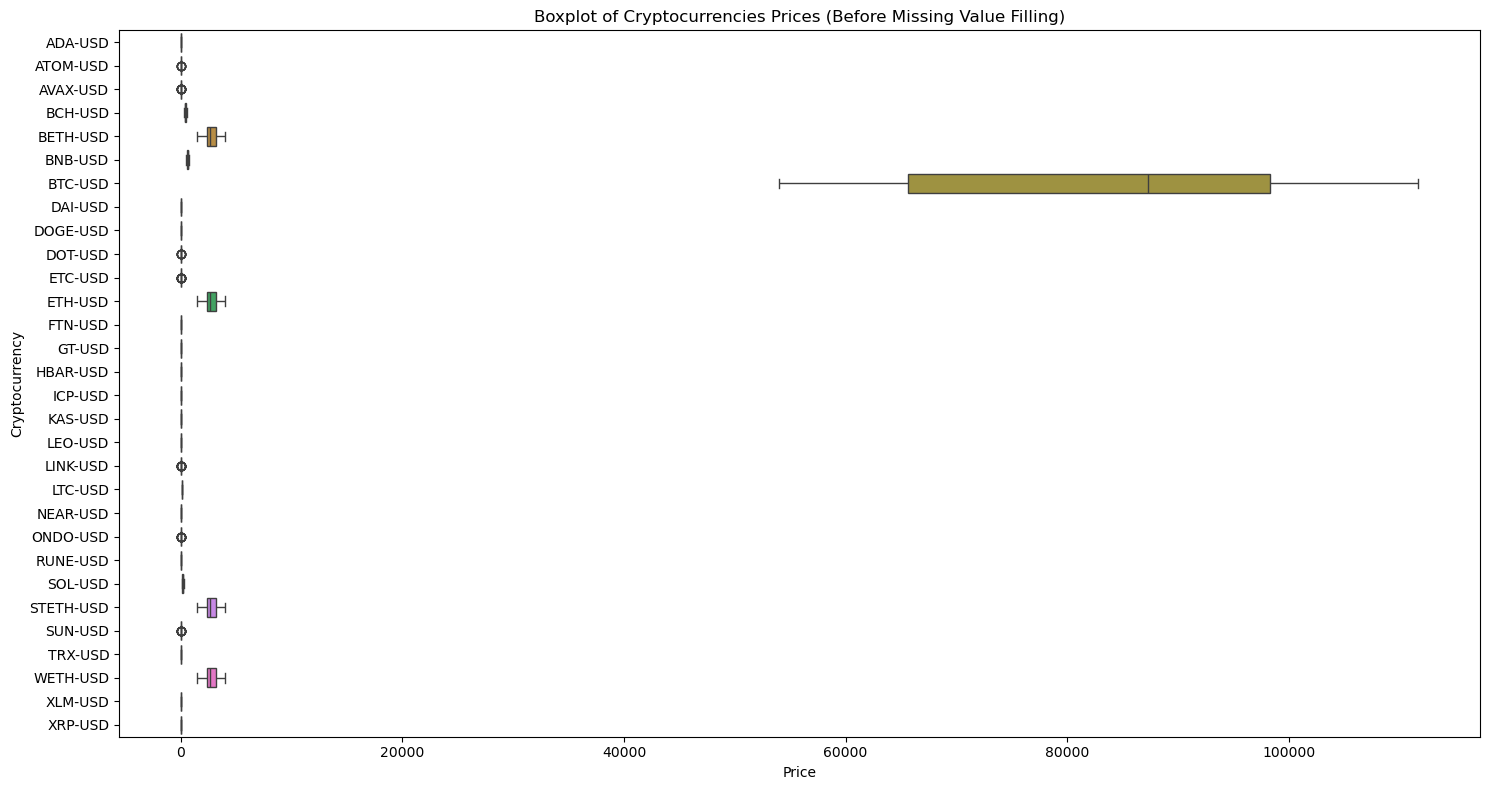

In [8]:
# Visualize boxplot before filling
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[price_columns], orient='h')
plt.title('Boxplot of Cryptocurrencies Prices (Before Missing Value Filling)')
plt.xlabel('Price')
plt.ylabel('Cryptocurrency')
plt.tight_layout()
plt.show()

In [9]:
# Fill missing values along the time axis:
# Sort by Date before filling to maintain temporal consistency
df = df.sort_values('Date')

# Forward fill then backward fill (along time axis) to maintain price continuity
df[price_columns] = df[price_columns].ffill(axis=0).bfill(axis=0)

# Fill any remaining missing values with median of each column (robust to skew)
df[price_columns] = df[price_columns].fillna(df[price_columns].median())

# Confirm no missing values remain
missing_after = df.isnull().sum().sum()
print(f"\nTotal missing values after outlier handling and imputation: {missing_after}")


Total missing values after outlier handling and imputation: 0


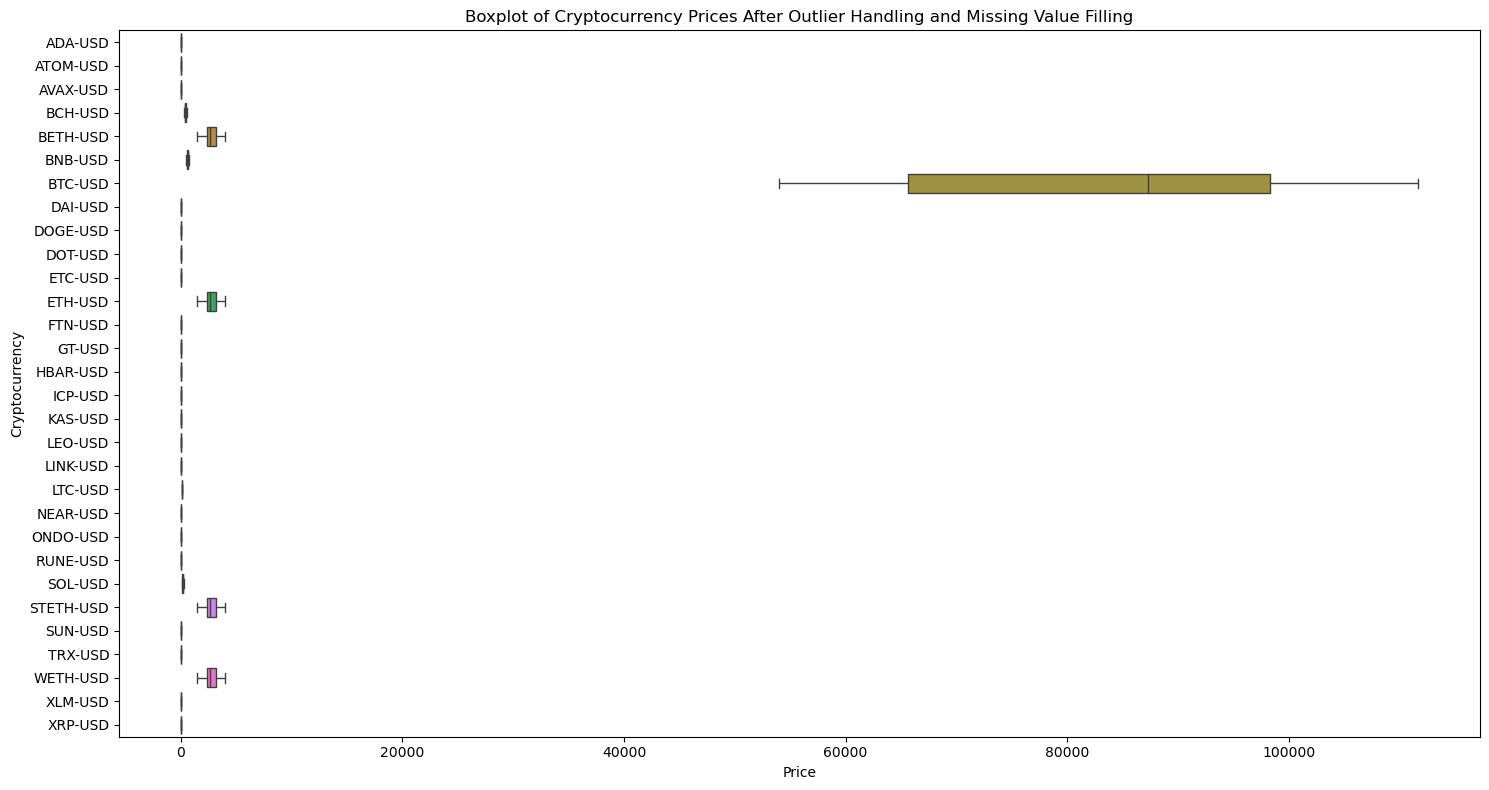

In [10]:
# Visualize boxplot after filling
plt.figure(figsize=(15, 8))
sns.boxplot(data=df[price_columns], orient='h')
plt.title('Boxplot of Cryptocurrency Prices After Outlier Handling and Missing Value Filling')
plt.xlabel('Price')
plt.ylabel('Cryptocurrency')
plt.tight_layout()
plt.show()

In [11]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\n🔁 Duplicate Rows Found: {duplicates}")


🔁 Duplicate Rows Found: 0


In [12]:
# Display summary statistics post-cleaning
print("\n📉 Summary Statistics (after cleaning):")
print(df.describe())


📉 Summary Statistics (after cleaning):
                                Date     ADA-USD    ATOM-USD    AVAX-USD  \
count                            365  365.000000  365.000000  365.000000   
mean   2024-12-29 23:59:59.999999744    0.641299    5.209543   26.204357   
min              2024-07-01 00:00:00    0.313155    3.592213   15.994716   
25%              2024-09-30 00:00:00    0.373214    4.352557   21.227669   
50%              2024-12-30 00:00:00    0.661447    4.757533   24.986889   
75%              2025-03-31 00:00:00    0.800345    6.069368   29.154499   
max              2025-06-30 00:00:00    1.231107    8.588020   40.248493   
std                              NaN    0.248378    1.207659    6.349266   

          BCH-USD     BETH-USD     BNB-USD        BTC-USD     DAI-USD  \
count  365.000000   365.000000  365.000000     365.000000  365.000000   
mean   384.990130  2687.752624  613.329447   84046.393440    0.999949   
min    268.966736  1464.903687  464.626923   53948.75390

In [13]:
# Check low variance columns which might be irrelevant
numeric_cols = [col for col in df.columns if pd.api.types.is_numeric_dtype(df[col])]
low_var_cols = [col for col in numeric_cols if df[col].std() < 1e-5]
print("\nColumns with near-zero variance:", low_var_cols)


Columns with near-zero variance: []


In [14]:
# Save the cleaned and preprocessed dataset for EDA, PCA, and clustering downstream
df.to_csv('../data/cleaned/crypto_dataset_cleaned.csv', index=False)
print("\n✅ Cleaned dataset saved as '../data/cleaned/crypto_dataset_cleaned.csv'")


✅ Cleaned dataset saved as '../data/cleaned/crypto_dataset_cleaned.csv'
